#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 3: Demanda de bicicletas compartidas  </center>

# Introducción

En esta actividad se trabajará sobre el *dataset* de la competencia [*Bike Sharing Demand*](https://www.kaggle.com/c/bike-sharing-demand) de *Kaggle*. El objetivo de la competencia, predecir la demanda de bicicletas a partir de la combinación de datos históricos sobre demanda y clima. 

El conjunto corresponde a datos de alquiler por hora y abarca dos años de información. El subconjunto de *train* está compuesto por los primeros 19 días de cada mes, mientras que el subconjunto de *test* va desde el día 20 hasta el final del mes. Este último debe ser utilizado solamente en la parte 10 para subir los resultados a la página de la competencia.

En esta actividad nos centraremos en el algoritmo **Decision Trees**, el cual al igual que *SVM* es un algoritmo versátil que se utiliza en problemas tanto de clasificación como de regresión. También trabajaremos con algoritmos basados en métodos de ensamble de estimadores, como son **Random Forest** y **Gradient Boosting**, que utilizan como estimador base **Decision Trees**.


## Objetivos


*   Conocer los estimadores *Decision Trees*, entender cómo funcionan para un problema de regresión, ver ventajas y desventajas.
*   Familiarizarse con los métodos de ensamblado de estimadores y entender cuál es el objetivo de usar estos métodos.
*   Incorporar una función de transformación de columnas y una función de medida de desempeño personalizadas.


## Formas de trabajo

#### Opción 1: Trabajar localmente


##### Ambiente de trabajo

Asegúrese estar trabajando en el ambiente de desarrollo creado en el Taller 1. Por ejemplo, habiendo ejecutado el notebook con el ambiente activado.  

Desde línea de comando puede consultar los ambientes disponibles con el comando: `conda info --envs`. 

Para activar el ambiente haga: `conda activate nombre_ambiente`
 

#####  1.1 Configuración del API token de Kaggle

A continuación, vaya a su cuenta de [Kaggle](https://www.kaggle.com/) (o cree una si aún no lo ha hecho), haga clic en el icono de perfil en la esquina superior derecha de la pantalla y seleccione "Your Account" en la lista desplegable. Luego, seleccione la viñeta "Settings" y en la sección API, ir a la subsección "Legacy API Credentials". Allí, cliquear en  "Create a Legacy API Key". Entonces un archivo llamado kaggle.json se descargará automáticamente a su carpeta de descargas. Este archivo contiene sus credenciales de inicio de sesión para permitirle acceder a la API.



Cree (en caso de no existir) la carpeta `.kaggle`. Modifique *nombre_usuario* por el nombre del usuario donde está trabajando.

Windows
```bash
!mkdir C:\Users\nombre_usuario\.kaggle
```

Linux
```bash
!mkdir ~/.kaggle
```



Mueva el archivo descargado a la carpeta creada.

Windows
```bash
!move C:\Users\nombre_usuario\Downloads\kaggle.json C:\Users\nombre_usuario\.kaggle
```
Linux
```bash
!mv ~/Downloads\kaggle.json ~/.kaggle
```

##### 1.2 Descarga de los datos

#####  Unirse a la competencia



Vaya a la competencia de [Bike sharing demand](https://www.kaggle.com/competitions/bike-sharing-demand/) y presione **Join Competition** o **Late Submission** y acepte las condiciones de la competencia

##### Descargar y descomprimir los datos

In [172]:
import os
from pathlib import Path

project_root = Path.cwd()
kaggle_dir = project_root / "keys"
kaggle_file = kaggle_dir / "kaggle.json"
data_dir = project_root / "data" / "data_taller3"
data_dir.mkdir(parents=True, exist_ok=True)

if not kaggle_file.exists():
    raise FileNotFoundError(
        f"No se encontro {kaggle_file.resolve()}. Descargue kaggle.json desde Kaggle y guardelo en keys/kaggle.json"
    )

if os.name != "nt":
    kaggle_file.chmod(0o600)

os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir.resolve())
print(f"KAGGLE_CONFIG_DIR = {os.environ['KAGGLE_CONFIG_DIR']}")
print(f"Usando credenciales de {kaggle_file.resolve()}")
print(f"Los datos se guardaran en {data_dir.resolve()}")

KAGGLE_CONFIG_DIR = /home/santig14/fing/taa/talleres/keys
Usando credenciales de /home/santig14/fing/taa/talleres/keys/kaggle.json
Los datos se guardaran en /home/santig14/fing/taa/talleres/data/data_taller3


Descomprima el archivo descargado:

In [173]:
!mkdir -p data/data_taller3 && kaggle competitions download -c bike-sharing-demand -p data/data_taller3

import shutil
shutil.unpack_archive("data/data_taller3/bike-sharing-demand.zip", "data/data_taller3")

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
bike-sharing-demand.zip: Skipping, found more recently modified local copy (use --force to force download)


-----

#### Opción 2:  Trabajar en *Colab*. 

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.  

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2026/blob/main/talleres/taller3_demanda_de_bicicletas.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>



La siguiente celda monta el disco personal del drive:

In [174]:
# from google.colab import drive
# drive.mount('/content/drive')

####  2.1 Configuración del API token en Colab

A continuación, vaya a su cuenta de [Kaggle](https://www.kaggle.com/) (o cree una si aún no lo ha hecho), haga clic en el icono de perfil en la esquina superior derecha de la pantalla y seleccione "Your Account" en la lista desplegable. Luego, seleccione la viñeta "Settings" y en la sección API, ir a la subsección "Legacy API Credentials". Allí, cliquear en  "Create a Legacy API Key". Entonces un archivo llamado kaggle.json se descargará automáticamente a su carpeta de descargas. Este archivo contiene sus credenciales de inicio de sesión para permitirle acceder a la API.

La siguiente celda realiza la configuración necesaria para obtener datos desde la plataforma Kaggle. Le solicitará que suba el archivo kaggle.json descargado anteriormente.

In [175]:
# import warnings
# warnings.filterwarnings('ignore')
# from google.colab import files

# El siguiente archivo solicitado es para habilitar la API de Kaggle en el entorno que está trabajando.
# Este archivo se descarga entrando a su perfíl de Kaggle, en la sección Settings/API, presionando donde dice: Create New Token

# uploaded = files.upload()

# for fn in uploaded.keys():
#     print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))

# #Then move kaggle.json into the folder where the API expects to find it.
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

#### 2.2 Descarga de los datos

#####  Unirse a la competencia



Vaya a la competencia de [Bike sharing demand](https://www.kaggle.com/competitions/bike-sharing-demand/) y presione **Join Competition** o **Late Submission** y acepte las condiciones de la competencia

#####  Instalar el paquete *kaggle*

Para obtener los datos de Kaggle primero se instalará la biblioteca de **Kaggle**

In [176]:
# !pip install kaggle

Si la instalación fue exitosa, el siguiente comando debería mostrar una lista de todas las competiciones activas de Kaggle.

In [177]:
# !kaggle competitions list

####  Descargar y descomprimir los datos

Ejecutar el siguiente comando para bajar los datos de la competencia *titanic*.

In [178]:
# !kaggle competitions download -c bike-sharing-demand

Descomprima el archivo descargado:

In [179]:
# Forma 1
# !unzip bike-sharing-demand.zip

# Forma 2
# import zipfile
# with zipfile.ZipFile("bike-sharing-demand.zip","r") as zip_ref:
#     zip_ref.extractall("./")

----

----

## Paquetes a utilizar

En esta actividad se utilizarán algunas bibliotecas auxiliares que deberán ser instaladas. Ejecutar la siguiente celda hasta que se ejecute sin errores. En caso de error, se puede instalar el paquete faltante desde el notebook con el comando:

`!pip install paquete_faltante`

In [180]:
#import comet_ml in the top of your file
from comet_ml import Experiment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

## (Opcional) librería de visualización de datos
import seaborn as sns
sns.set_theme(style="whitegrid")

data_dir = Path("data") / "data_taller3"
df_train = pd.read_csv(data_dir / 'train.csv')
df_test = pd.read_csv(data_dir / 'test.csv')
df_submission = pd.read_csv(data_dir / 'sampleSubmission.csv')

## Parte 1 - Análisis de los datos

#### Objetivos

 - Analizar el conjunto de datos con las diferentes funciones de *pandas* que crea pertinente.

El conjunto de datos tiene 10886 filas y 12 columnas.


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


Tipos de datos por columna:


,dtype
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


Datos faltantes por columna:


,missing_values
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


Cantidad de valores unicos por columna:


,unique_values
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


season: [1, 2, 3, 4]
holiday: [0, 1]
workingday: [0, 1]
weather: [1, 2, 3, 4]
Resumen descriptivo de las variables numericas:


,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


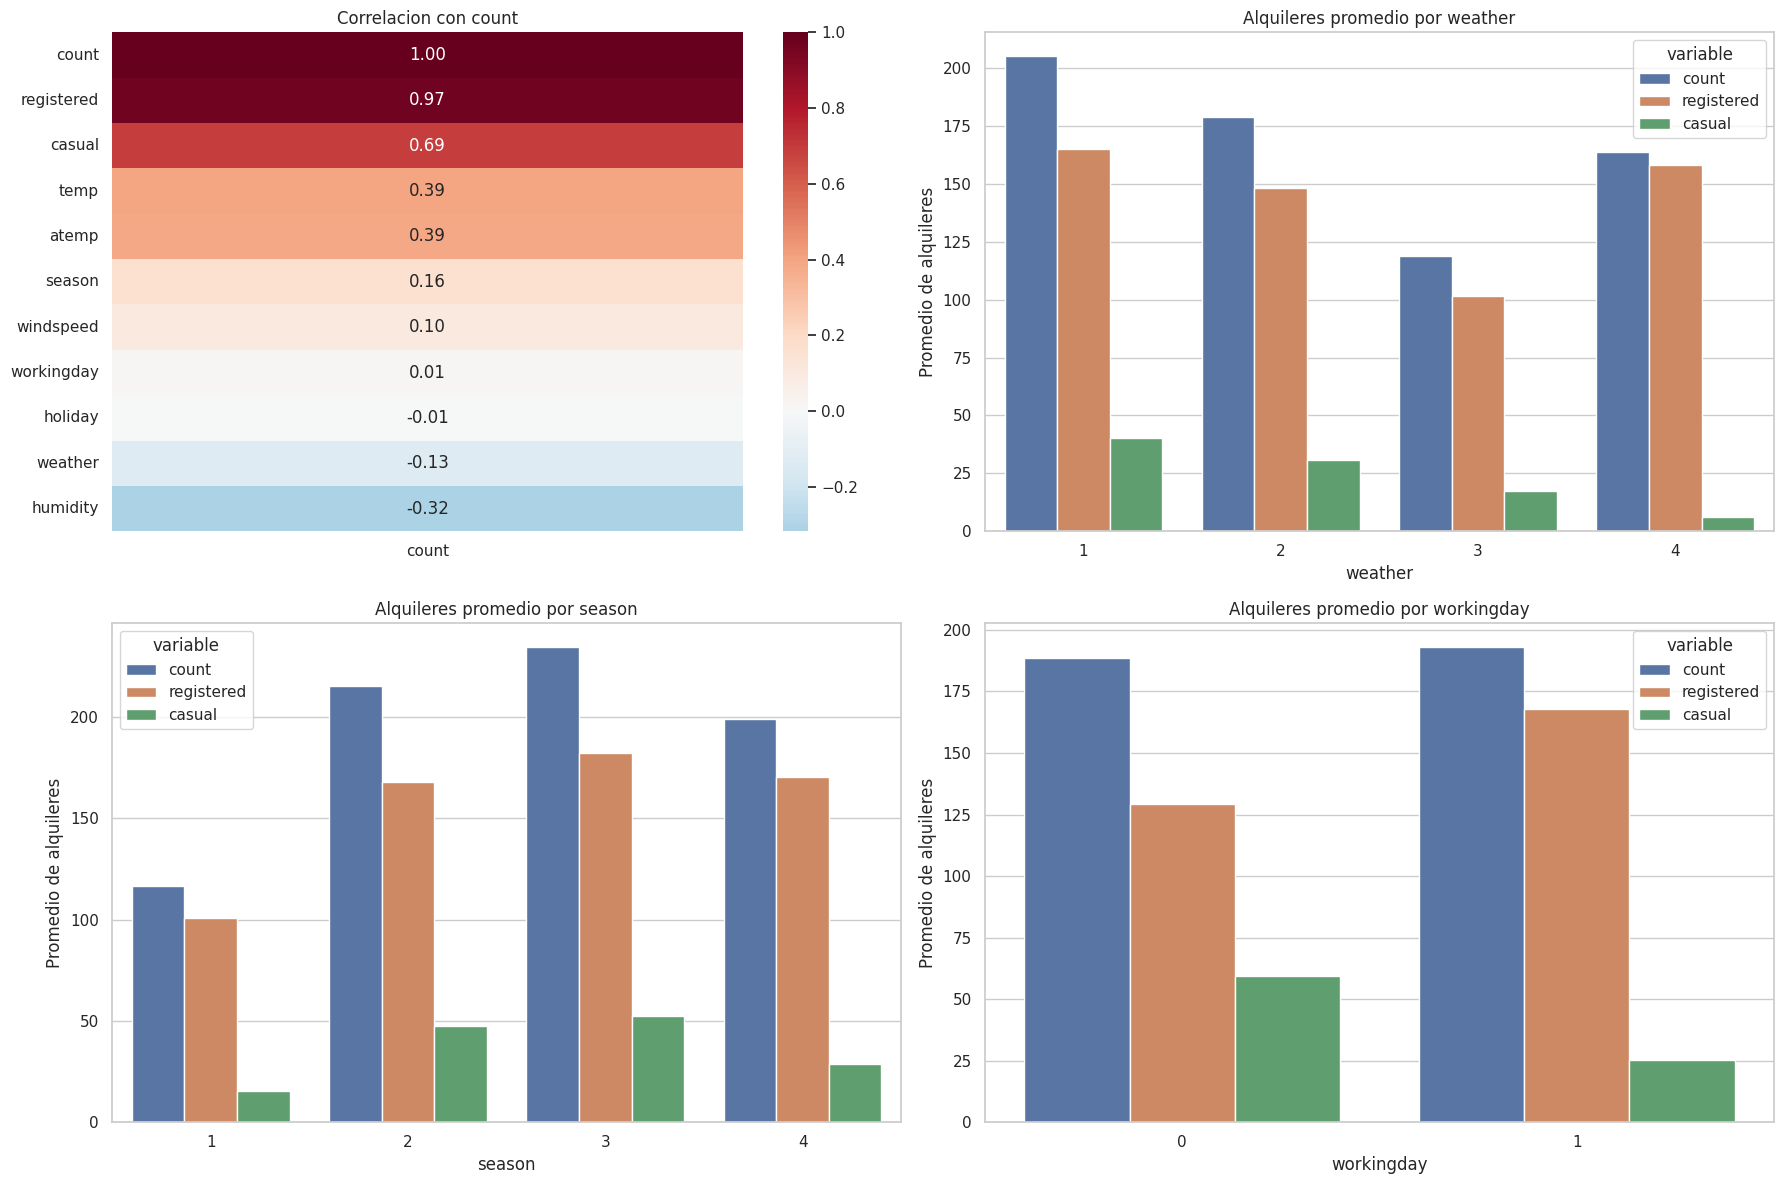

count = casual + registered en todas las filas: True


In [181]:
from IPython.display import display

print(f"El conjunto de datos tiene {df_train.shape[0]} filas y {df_train.shape[1]} columnas.")
display(df_train.head(15))

print("Tipos de datos por columna:")
display(df_train.dtypes.to_frame("dtype"))

print("Datos faltantes por columna:")
display(df_train.isna().sum().to_frame("missing_values"))

print("Cantidad de valores unicos por columna:")
display(df_train.nunique().to_frame("unique_values"))

for column in ["season", "holiday", "workingday", "weather"]:
    print(f"{column}: {sorted(df_train[column].unique().tolist())}")

print("Resumen descriptivo de las variables numericas:")
display(df_train.describe().T)

count_correlations = (
    df_train.select_dtypes(include=np.number)
    .corr(numeric_only=True)[["count"]]
    .sort_values("count", ascending=False)
)

weather_plot_data = (
    df_train.groupby("weather")[["count", "registered", "casual"]]
    .mean()
    .round(2)
    .reset_index()
    .melt(id_vars="weather", var_name="user_type", value_name="mean_rentals")
)
season_plot_data = (
    df_train.groupby("season")[["count", "registered", "casual"]]
    .mean()
    .round(2)
    .reset_index()
    .melt(id_vars="season", var_name="user_type", value_name="mean_rentals")
)
workingday_plot_data = (
    df_train.groupby("workingday")[["count", "registered", "casual"]]
    .mean()
    .round(2)
    .reset_index()
    .melt(id_vars="workingday", var_name="user_type", value_name="mean_rentals")
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.heatmap(
    count_correlations,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Correlacion con count")

sns.barplot(
    data=weather_plot_data,
    x="weather",
    y="mean_rentals",
    hue="user_type",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Alquileres promedio por weather")
axes[0, 1].set_xlabel("weather")
axes[0, 1].set_ylabel("Promedio de alquileres")

sns.barplot(
    data=season_plot_data,
    x="season",
    y="mean_rentals",
    hue="user_type",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Alquileres promedio por season")
axes[1, 0].set_xlabel("season")
axes[1, 0].set_ylabel("Promedio de alquileres")

sns.barplot(
    data=workingday_plot_data,
    x="workingday",
    y="mean_rentals",
    hue="user_type",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Alquileres promedio por workingday")
axes[1, 1].set_xlabel("workingday")
axes[1, 1].set_ylabel("Promedio de alquileres")

for ax in axes.flat[1:]:
    ax.legend(title="variable")

plt.tight_layout()
plt.show()

print(
    "count = casual + registered en todas las filas:",
    ((df_train["casual"] + df_train["registered"]) == df_train["count"]).all(),
)


#### Preguntas:

 - ¿Qué efecto tiene el tiempo (meteorológico) sobre el alquiler de bicicletas? ¿Es el mismo para clientes registrados y casuales? ¿Coincide esto con lo que asumiría a priori? 
 - Vamos a trabajar con las codificaciones por defecto (salvo datetime que veremos en la Parte 2). ¿Le parece adecuado?
 - ¿Qué puede decir sobre la correlación entre *season* y *casual*?


### Respuestas

 - El conjunto tiene unas 10886 entradas con 12 columnas sin ningun dato faltante, tenemos variables como season, holiday, workingday y weather que son categoricas
 - El tiempo inlfuye de gran medida sobre la demanda, de forma esperable, a peor clima menor cantidad de alquileres, y mejor clima, mas alquileres siendo mas impacto en usuarios casuales que en registrados. Esto tiene sentido a priori ya que los usuarios registrados tienen a no variar mucho su uso por el clima ya que lo usarian para actividades recurendes, mientras que los usuarios casuales aprovecharian justamente los dias lindos.
 - La codificacion por defecto puede ser buena para arboles, ya que son medio indiferentes con los datos que imponen un orden y distancias artificiales entre categorias.
 - Como hablamos antes, tienen bastante correlacion lo que tiene mucho sentido.


## Parte 2 - Características temporales

La primera columna de los datos (*datetime*) corresponde a las marcas de tiempo asociadas a cada instancia. Para que estos tengan el orden cronológico que representan es necesario pasarlos de tipo *string* a tipo *datetime*. Para esto *Pandas* proporciona la función *to_datetime()*. Correr la siguiente celda para hacer el cambio.

In [182]:
df_train['datetime'] = pd.to_datetime(df_train['datetime'])

##### La figura siguiente muestra cómo varía la cantidad de bicicletas alquiladas en función del tiempo. 

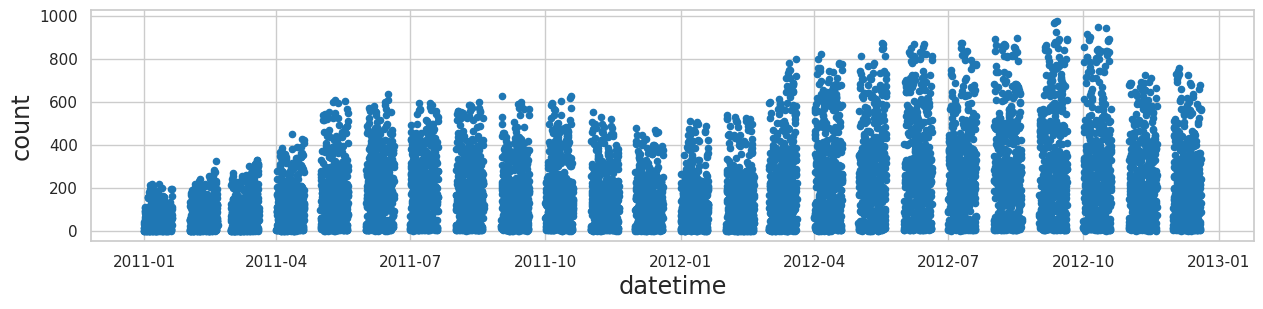

In [183]:
df_train.plot(x='datetime', y='count', figsize=[15,3],kind='scatter',color='tab:blue')
plt.xlabel('datetime',fontsize='x-large')
plt.ylabel('count',fontsize='x-large')
plt.show()

#### Preguntas:

- ¿Le parece razonable la division en conjuntos de train y test que se tomó en el desafío?
- ¿Cómo varían temporalmente (día, semana, mes, año) los alquileres?

### Respuestas
 - Me parecio una interesante forma de division, ya que apare de mantener el variado entre los dias del anio, tambien generea una interesante propuesta en el hecho de poder predecir la demanda que va a haber en algun mes teniendo los datos de inicio de mes.
 - Lo negativo es que el modelo quiza pierde un poco de informacion al no poder entrenar con datos del uso a fin de mes, que en el sueldo de mucha gente puede variar.

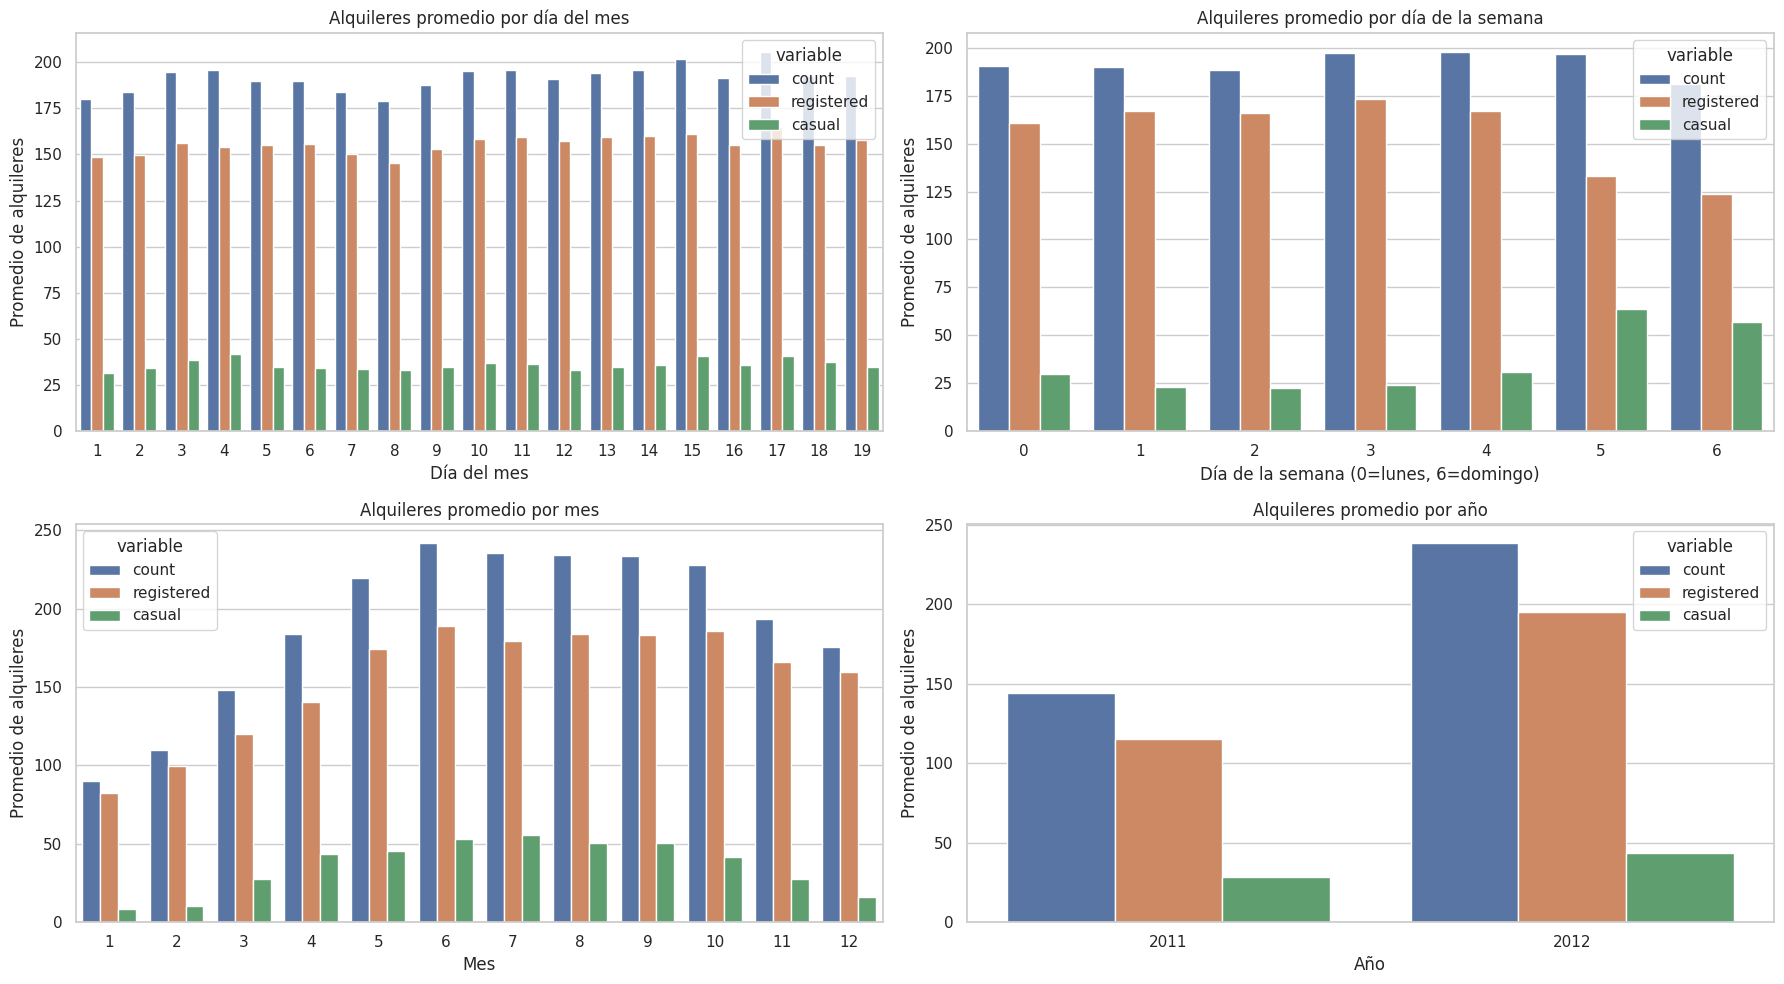

In [184]:
df_train["day"] = df_train["datetime"].dt.day
df_train["weekday"] = df_train["datetime"].dt.weekday
df_train["month"] = df_train["datetime"].dt.month
df_train["year"] = df_train["datetime"].dt.year

target_columns = ["count", "registered", "casual"]

day_plot_data = (
    df_train.groupby("day")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="day", var_name="user_type", value_name="mean_rentals")
)
weekday_plot_data = (
    df_train.groupby("weekday")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="weekday", var_name="user_type", value_name="mean_rentals")
)
month_plot_data = (
    df_train.groupby("month")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="month", var_name="user_type", value_name="mean_rentals")
)
year_plot_data = (
    df_train.groupby("year")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="year", var_name="user_type", value_name="mean_rentals")
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=day_plot_data, x="day", y="mean_rentals", hue="user_type", ax=axes[0, 0])
axes[0, 0].set_title("Alquileres promedio por día del mes")
axes[0, 0].set_xlabel("Día del mes")
axes[0, 0].set_ylabel("Promedio de alquileres")

sns.barplot(data=weekday_plot_data, x="weekday", y="mean_rentals", hue="user_type", ax=axes[0, 1])
axes[0, 1].set_title("Alquileres promedio por día de la semana")
axes[0, 1].set_xlabel("Día de la semana (0=lunes, 6=domingo)")
axes[0, 1].set_ylabel("Promedio de alquileres")

sns.barplot(data=month_plot_data, x="month", y="mean_rentals", hue="user_type", ax=axes[1, 0])
axes[1, 0].set_title("Alquileres promedio por mes")
axes[1, 0].set_xlabel("Mes")
axes[1, 0].set_ylabel("Promedio de alquileres")

sns.barplot(data=year_plot_data, x="year", y="mean_rentals", hue="user_type", ax=axes[1, 1])
axes[1, 1].set_title("Alquileres promedio por año")
axes[1, 1].set_xlabel("Año")
axes[1, 1].set_ylabel("Promedio de alquileres")

for ax in axes.flat:
    ax.legend(title="variable")

plt.tight_layout()
plt.show()


### Respuestas
  - Por dia de la semana, el total promedio no cambia tanto, pero si cambia si miramos solo los casuales, teniendo un casi x en los fin de semanas
  - Por mes y estacion se observa una demanda mayor en meses templados/calidos, especialmente de primavera/verano, y  menor en invierno.
  - Por ano se ve un crecimiento claro, el promedio de alquileres en 2012 es bastante mayor que en 2011

El tipo de dato *datetime* permite extraer de forma sencilla datos categóricos como la hora, el día de la semana, entre otros. La siguiente celda agrega a los datos de *train* estas nuevas características.

In [185]:
df_train['hour'] = df_train['datetime'].dt.hour
df_train['weekday'] = df_train['datetime'].dt.weekday

df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day,weekday,month,year,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,5,1,2011,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1,2011,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,5,1,2011,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,5,1,2011,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,5,1,2011,4


#### Ejercicio:

 - Grafique count, registered y casual en función de las horas y el día de la semana. ([*Sugerencia:*](https://seaborn.pydata.org/generated/seaborn.barplot.html) Ejemplos de la biblioteca *seaborn*)

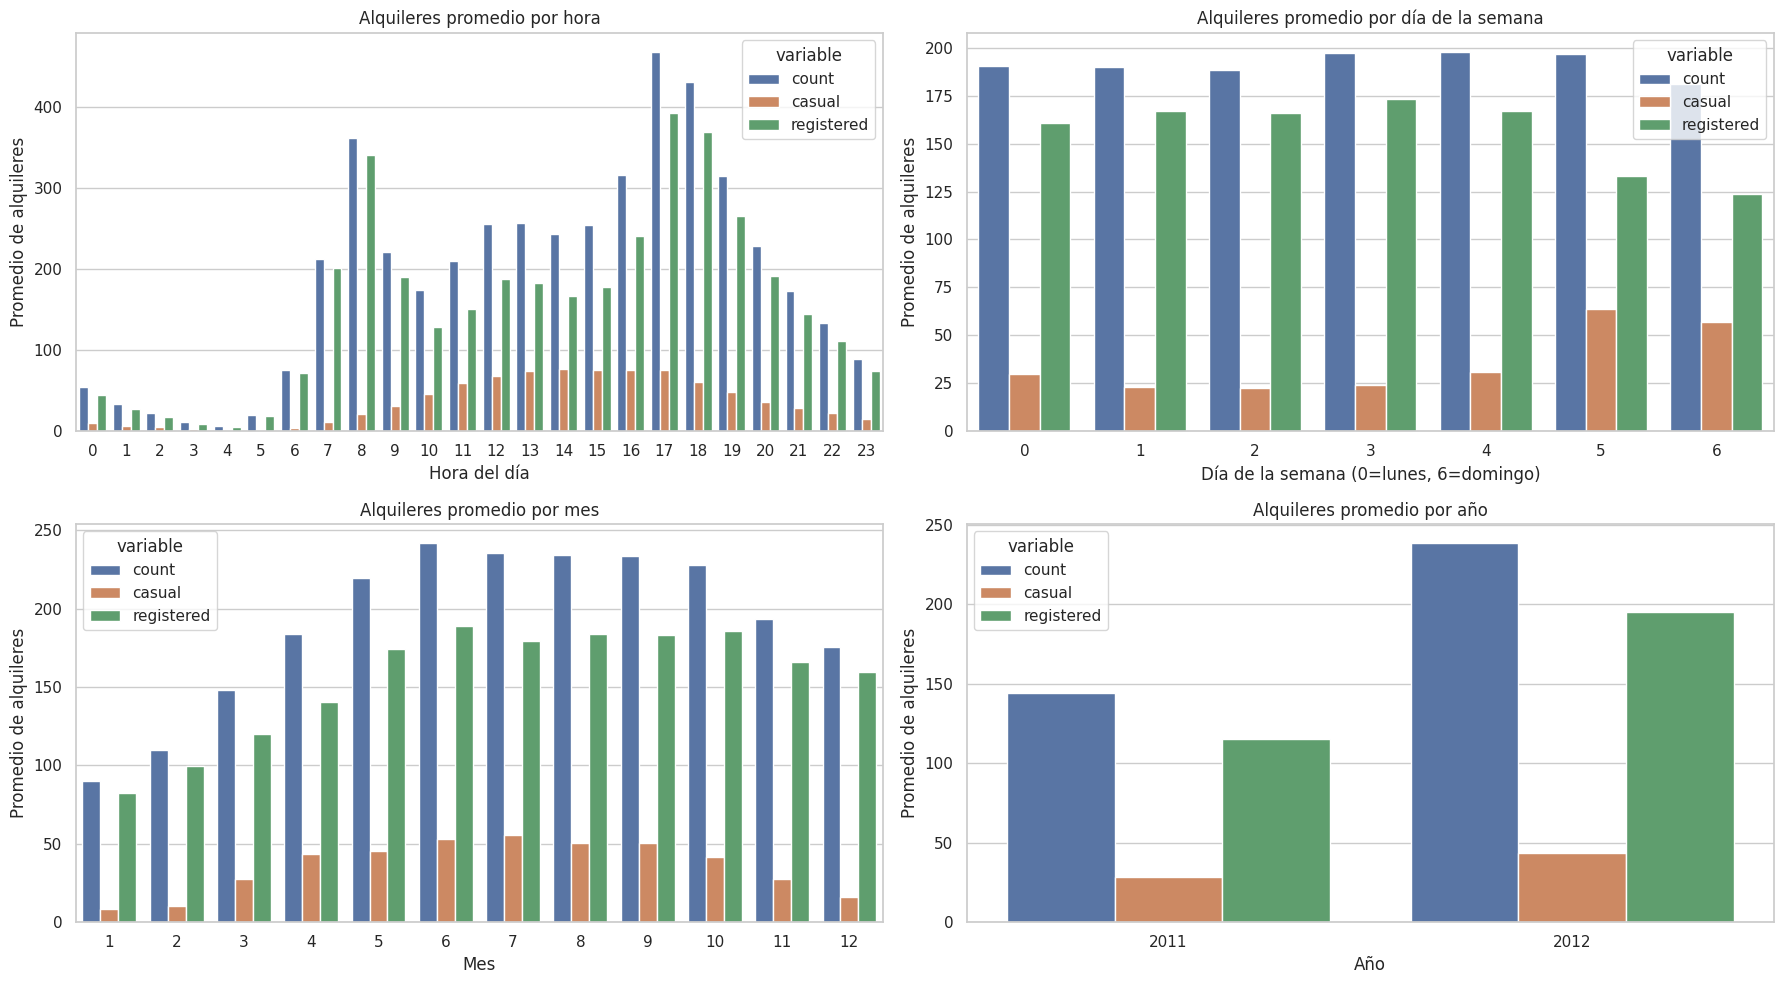

In [186]:
df_train["month"] = df_train["datetime"].dt.month
df_train["year"] = df_train["datetime"].dt.year

target_columns = ["count", "casual", "registered"]

hour_plot_data = (
    df_train.groupby("hour")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="hour", var_name="user_type", value_name="mean_rentals")
)
weekday_plot_data = (
    df_train.groupby("weekday")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="weekday", var_name="user_type", value_name="mean_rentals")
)
month_plot_data = (
    df_train.groupby("month")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="month", var_name="user_type", value_name="mean_rentals")
)
year_plot_data = (
    df_train.groupby("year")[target_columns]
    .mean()
    .reset_index()
    .melt(id_vars="year", var_name="user_type", value_name="mean_rentals")
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=hour_plot_data, x="hour", y="mean_rentals", hue="user_type", ax=axes[0, 0])
axes[0, 0].set_title("Alquileres promedio por hora")
axes[0, 0].set_xlabel("Hora del día")
axes[0, 0].set_ylabel("Promedio de alquileres")

sns.barplot(data=weekday_plot_data, x="weekday", y="mean_rentals", hue="user_type", ax=axes[0, 1])
axes[0, 1].set_title("Alquileres promedio por día de la semana")
axes[0, 1].set_xlabel("Día de la semana (0=lunes, 6=domingo)")
axes[0, 1].set_ylabel("Promedio de alquileres")

sns.barplot(data=month_plot_data, x="month", y="mean_rentals", hue="user_type", ax=axes[1, 0])
axes[1, 0].set_title("Alquileres promedio por mes")
axes[1, 0].set_xlabel("Mes")
axes[1, 0].set_ylabel("Promedio de alquileres")

sns.barplot(data=year_plot_data, x="year", y="mean_rentals", hue="user_type", ax=axes[1, 1])
axes[1, 1].set_title("Alquileres promedio por año")
axes[1, 1].set_xlabel("Año")
axes[1, 1].set_ylabel("Promedio de alquileres")

for ax in axes.flat:
    ax.legend(title="variable")

plt.tight_layout()
plt.show()

##### A partir de las gráficas responder las siguientes preguntas:

 - ¿Cómo explicaría la diferencia entre las distribuciones de los clientes registrados y casuales? 
 - ¿Qué desventaja le encuentra a utilizar un regresor lineal para predecir los alquileres a partir de la hora del día?¿Cómo transformaría esta característica para paliar este problema?
 - ¿Es necesaria esta transformación cuando se utilizan Árboles de Decisión?

### Respuestas
- Los usuarios tienen una distribucion muy marcada por lo que supongo su rutina laboral, aparecen picos grandes cerca de las 8 y luego sobre las 17/18, esto lleva la logica de que los usuarios que mas utilizan las bicicletas (por ejemplo para ir a trabajar dia a dia) les conviene asociarse. Mientras que los casuales tienen un comportamiento mas correspondiente a horarios recreativos.
- Para apaliar estos problemas o como la hora es ciclica, se podria usar tanto codificacion con seno y coseno, utilizar one hot para cada hora o agruparlas en fragmentos y tenerlas en one-hot tambien.
- En arboles no es tan necesario, ya que estos pueden separar ariables mediante umbrales y capturar relaciones no lineales. Si bien no es estrictamente necesario, serviria de mucho.

#### Selección de Características:

*   Entre el día, el mes y el año ¿cuáles de estos datos les pareces agregar como nuevas características y cuáles no? y ¿Por qué?
*   Agregar las características seleccionadas.

### Respuestas
- Agregaria mes por la informacion de clima, ya que esta cambia mucho en los meses frios contra los meses calidos.
- Luego ano tiene informacion importante ya que en 2012 la cantidad de alquileres es considerablemente mayor a 2011
- Pero el dia no, ya que este podria incluir informacion que no se encuentra precente dentro del test, ya que sabemos que los dias de train son del 1 al 19 mientras que test son del 20 a fin de mes.
- Mantendria hour y weekday porque explican patrones importantes de uso como los picos diarios y weekday ayuda a diferenciar rutinas.

## Parte 3 - Preparación de los datos y Métrica de evaluación

Previo a trabajar con los estimadores:

*   Apartar la columna objetivo y eliminarla del conjunto de entrenamiento. 
*   Eliminar las columnas *'casual'* y *'registered'*. ¿Por qué esto es necesario?.
*   Eliminar la columna *'datetime'*.

Durante la actividad los estimadores deben ser evaluados con la misma medida de desempeño utilizada en la competencia: 

Root Mean Squared Logarithmic Error (RMSLE)
$$\sqrt{\frac{1}{n}\sum_{i}^{n}\big(\log(y_{i} + 1) - \log(\hat{y}_{i} + 1)\big)^2}$$

Este tipo de medida se utiliza cuando los valores a estimar son grandes. La librería *Scikit-Learn* incluye la función de desempeño [*mean_squared_log_error*](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_log_error.html#sklearn.metrics.mean_squared_log_error) (MSLE), esta función se puede utilizar  para la validación ya que alcanza las mismas soluciones que su raíz (RMSLE). De igual forma los resultados se deben mostrar con RMSLE.  
También está disponible en versiones recientes (>=1.4) de *Scikit-Learn* la métrica [root_mean_squared_log_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_log_error.html).

### Respuestas
- Se eliminan casual y registered porque basicamente la variable objetivo es la suma exacta de ambos, por lo que si entran como features estaria recibiendo la respuesta exacta indirectamente

In [187]:
from IPython.display import display
from sklearn.metrics import make_scorer, mean_squared_log_error

df_train["datetime"] = pd.to_datetime(df_train["datetime"])
df_train["hour"] = df_train["datetime"].dt.hour
df_train["weekday"] = df_train["datetime"].dt.weekday
df_train["month"] = df_train["datetime"].dt.month
df_train["year"] = df_train["datetime"].dt.year

y_train = df_train["count"].copy()

columns_to_drop = ["casual", "registered", "count", "datetime", "day"]
df_train = df_train.drop(columns=columns_to_drop, axis=1, errors="ignore")

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

display(df_train.head())
print(f"X_train shape: {df_train.shape}")
print(f"y_train shape: {y_train.shape}")

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,weekday,month,year,hour
0,1,0,0,1,9.84,14.395,81,0.0,5,1,2011,0
1,1,0,0,1,9.02,13.635,80,0.0,5,1,2011,1
2,1,0,0,1,9.02,13.635,80,0.0,5,1,2011,2
3,1,0,0,1,9.84,14.395,75,0.0,5,1,2011,3
4,1,0,0,1,9.84,14.395,75,0.0,5,1,2011,4


X_train shape: (10886, 12)
y_train shape: (10886,)


## Parte 4 - Decision Trees

### TransformedTargetRegressor

Observando los valores de las etiquetas se puede ver que la distribución de estos tiene una asimetría a la derecha, por lo que se puede aplicar una transformación logarítmica para que la distribución de las etiquetas sea más normal.

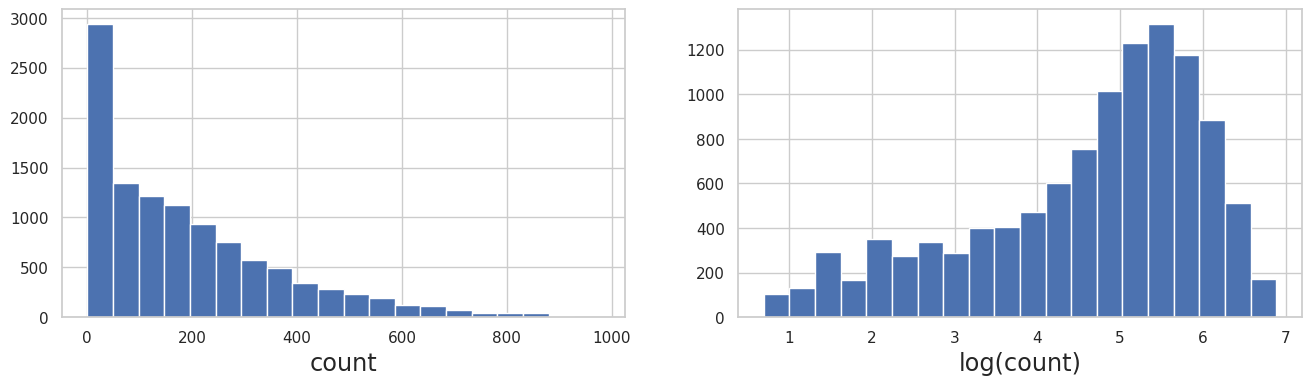

In [188]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
y_train.hist(bins=20)
plt.xlabel('count',fontsize='x-large')
plt.subplot(1,2,2)
np.log1p(y_train).hist(bins=20)
plt.xlabel('log(count)',fontsize='x-large')
plt.show()

Si le pasamos al regresor estas etqiquetas tranformadas este predecirá el logaritmo de los alquileres, por lo que luego deberíamos calcular la exponencial del valor predicho. Por suerte, Scikit-Learn cuenta con la función [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html) que resuelve este problema.

**Nota: Consultar el Capítulo 2 del Libro del Curso por más información**

#### Objetivos

*   Importar la función *DecisionTreeRegressor()* de *Scikit-Learn* y utilizar *TransformedTargetRegressor* para tranformar logarítmicamente las etiquetas. Utilizar las funciones ***np.log1p*** y ***np.expm1*** para calcular el logaritmo y la exponencial respectivamente (ver ejemplo en ayuda de la función *TransformedTargetRegressor*).
*   Aplicar validación cruzada (10-Folds) a un estimador con los hiper-parámetros por defecto.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Para lo último utilizar la función *fill_between()* de *matplotlib*. 

**Nota:** Puede pasarle ***random-state=2*** al estimador,*DecisionTreeRegressor()*,  para controlar la aleatoreidad del mismo. De no hacerlo puede que los resultados que obtenga difieran en cierta medida de los esperados.

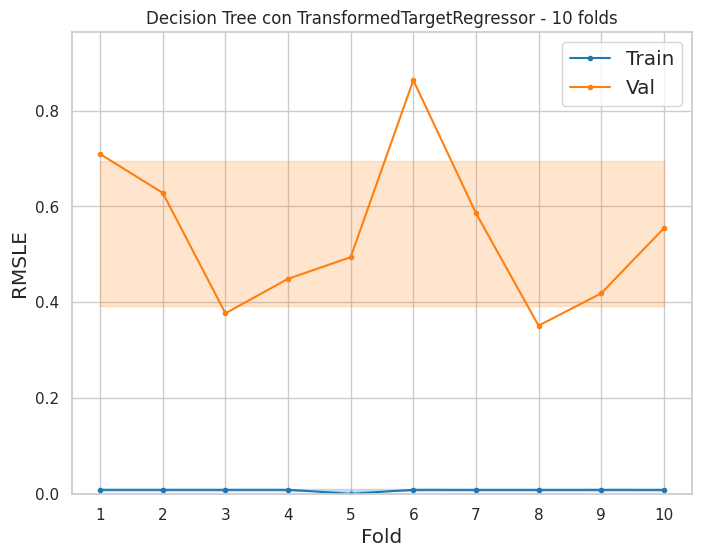

Train RMSLE: 0.0084 +/- 0.0024
Val RMSLE: 0.5433 +/- 0.1517


In [189]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor

regressor = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(random_state=2),
    func=np.log1p,
    inverse_func=np.expm1,
)

cv_results_tree = cross_validate(
    regressor,
    df_train,
    y_train,
    cv=10,
    scoring=rmsle_scorer,
    return_train_score=True,
)

rmsle_train = -cv_results_tree["train_score"]
rmsle_val = -cv_results_tree["test_score"]

mean_rmsle_train = rmsle_train.mean()
std_rmsle_train = rmsle_train.std()
mean_rmsle_val = rmsle_val.mean()
std_rmsle_val = rmsle_val.std()

folds = np.arange(1, len(rmsle_train) + 1)

plt.figure(figsize=(8, 6))
plt.plot(folds, rmsle_train, ".-", color="tab:blue", label="Train")
plt.plot(folds, rmsle_val, ".-", color="tab:orange", label="Val")

plt.fill_between(
    folds,
    mean_rmsle_train + std_rmsle_train,
    mean_rmsle_train - std_rmsle_train,
    color="tab:blue",
    alpha=0.2,
)
plt.fill_between(
    folds,
    mean_rmsle_val + std_rmsle_val,
    mean_rmsle_val - std_rmsle_val,
    color="tab:orange",
    alpha=0.2,
)

plt.xlabel("Fold", fontsize="large")
plt.ylabel("RMSLE", fontsize="large")
plt.title("Decision Tree con TransformedTargetRegressor - 10 folds")
plt.legend(fontsize="large")
plt.xticks(folds)
plt.ylim([0, max(rmsle_val.max(), rmsle_train.max()) + 0.1])
plt.show()

print(f"Train RMSLE: {mean_rmsle_train:.4f} +/- {std_rmsle_train:.4f}")
print(f"Val RMSLE: {mean_rmsle_val:.4f} +/- {std_rmsle_val:.4f}")

#### Preguntas:

*   ¿Qué fenómeno se logra apreciar en el gráfico? ¿A qué se debe? ¿Por qué esto es un problema?
*   Indicar y describir alguno de los hiper-parámetros que la función *DecisionTreeRegressor()* ofrece para limitar la complejidad del estimador.

### Respuestas
- Se aprecia un claro sobreajuste en los datos de train, el error RMSLE es casi cero, mientras que en validacion es muy mayor, esto indica que el arbol por defecto aprende demasiado de los datos de entrenamiento sin generalizar.
- Esto se puede deber que sin restricciones, el arbol puede crecer tanto hasta generar hojas muy especificas sin poder atrapar generalizaciones.
- Al memorizar o ajustarse tanto, es muy complicado poder predecir correctamente las nuevas observaciones.

Algunos hiperparametros que pueden servir son:
max_depth limitando la profundidad maxima
min_samples_leaf exigiendo una cantidad minima de muestras por hoja
min_samples_split exigiendo una cantidad mínima de muestras para dividir un nodo
max_leaf_nodes: limita la cantidad máxima de hojas del árbol

#### Ejemplo Lack of smoothness

Como ejemplo se tomará la siguiente situación:

 - Domingo 
 - Despejado o Parcialmente nublado
 - A las 19 horas 
 - En primavera 
 
Se observará el efecto de la temperatura en la predicción de alquileres de bicicletas.

 - ¿Cómo espera que sea dicho efecto en un rango de 10°C a 30°C?

In [190]:
index = 2685
Domingo = df_train.iloc[index:index+1]
Domingo

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,weekday,month,year,hour
2685,2,0,0,1,29.52,34.09,62,8.9981,6,6,2011,19


In [191]:
## Se crea un dataframe con los datos del domingo
X_prueba = pd.concat([Domingo]*21,ignore_index=True)

index = 0
for k in np.linspace(10,30,21):
    X_prueba.loc[index,'temp']= k
    ## De igual manera se cambia la sensación térmica para mantener cierta coherencia
    X_prueba.loc[index,'atemp']= k
    index += 1

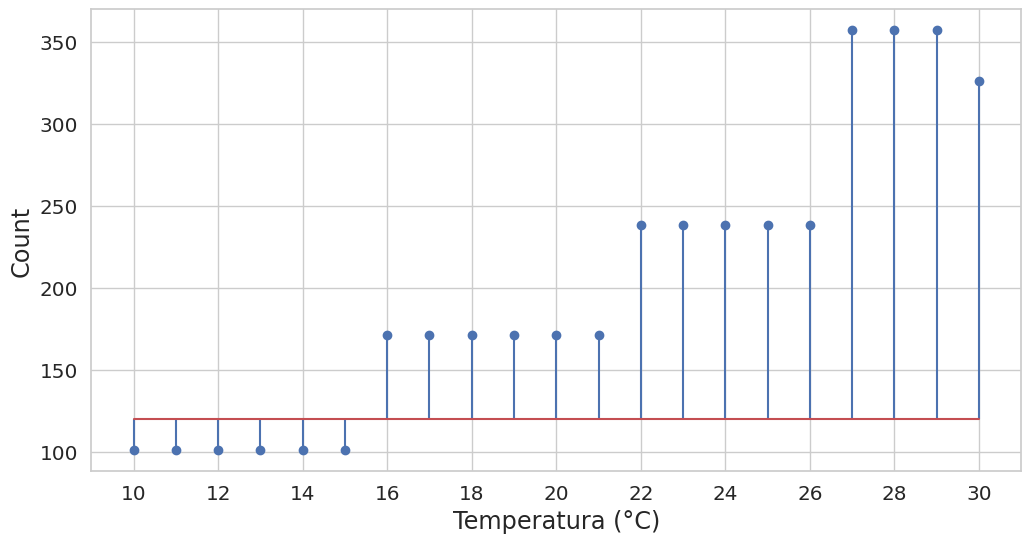

In [192]:
## regressor es el nombre de la variable que contiene el modelo de arbol de decisión
regressor.fit(df_train,y_train)

plt.figure(figsize=(12,6))
plt.stem(np.linspace(10,30,21),regressor.predict(X_prueba),bottom=120)
plt.xlabel('Temperatura (°C)',fontsize='x-large')
plt.ylabel('Count',fontsize='x-large')
plt.xticks(np.linspace(10,30,11),fontsize='large')
plt.yticks(fontsize='large')
plt.savefig('cambios_temp.png')
plt.show()

 - Observe el cambio que genera la temperatura a la salida (en particular el pasar de una temperatura de 23°C a 24°C, puede variar según la semilla, ver **Nota**).
 
 - ¿Qué desventaja le encuenta a los árboles de decisión en comparación con modelos lineales?

 **Nota:** Debido a la alta varianza de los Árboles de decisión los modelos obtenidos pueden variar de gran manera a efecto de pequeños cambios en el entrenamiento. En la carpeta se adjunta la imagen *cambios_temp.png* para que pueda discutir las preguntas a partir de la figura que se espera obtener.

### Respuestas

- En un cambio de 10 a 30 se esperaria que aumente relativamente bastante ya que para temperatura es un salto grande dentro de su rango
- Creo que la desventaga mas grande es que se generan funciones escalonadas y no relaciones suaves

### Ajuste Fino

#### Objetivos

*   Seleccionar uno de los hiper-parámetros y encontrar el mejor estimador.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Comparar con los resultados anteriores.
*   Graficar cómo varían los valores de RMSLE de entrenamiento y validación, para diferentes valores del hiper-parámetro.
*   Mostrar el mejor valor RMSLE (promedio de todos los *folds*) y el valor del hiper-parámetro.
*   Visualizar el árbol hasta los nodos de profundidad 2 utilizando la función *plot_tree()*. Agrandar el tamaño de la imagen de manera de poder leer la descripción de cada nodo.
*   Analizar las decisiones que está tomando el árbol para los primeros nodos.
*   Graficar los primeros 200 valores objetivo junto con sus predicciones.

**Nota:** Puede ser útil la función *save_gs_results()* que se encuentra en el archivo *comet_log.py* de la carpeta del taller para organizar sus experimentos con Comet.

In [193]:
# Iniciar el experimento a loguear en Comet
log_to_comet = True
exp_tree = None

if log_to_comet:
    try:
        exp_tree = Experiment(
            project_name="bike_sharing_demand",
            log_git_metadata=False,
            log_git_patch=False,
            auto_param_logging=False,
        )
        exp_tree.set_name("Decision Tree - ajuste fino max_depth")
        exp_tree.add_tags(["DecisionTree", "GridSearchCV", "max_depth"])
    except Exception as exc:
        exp_tree = None
        print(f"No se pudo iniciar el experimento en Comet: {exc}")
else:
    print("Comet desactivado para esta ejecucion. Cambiar log_to_comet=True para loguear.")


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/srodriguez-lefebre/bike-sharing-demand/7685be4c82ec44049db69a71d5fb88b9



In [194]:
# 1. Elegir uno de los hiper-parámetros, Por ejemplo max_depth
hyperparameter_name = "regressor__max_depth"

# 2. Definir la lista de valores a explorar
max_depth_values = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
param_grid_tree = {hyperparameter_name: max_depth_values}

# 3. Crear el regresor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import make_scorer, mean_squared_log_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

tree_regressor = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(random_state=2),
    func=np.log1p,
    inverse_func=np.expm1,
)

# 4. Crear el GridSearchCV
msle_scorer = make_scorer(mean_squared_log_error, greater_is_better=False)

gs_tree = GridSearchCV(
    estimator=tree_regressor,
    param_grid=param_grid_tree,
    scoring={"NMSLE": msle_scorer, "RMSLE": rmsle_scorer},
    refit="NMSLE",
    cv=10,
    return_train_score=True,
    n_jobs=-1,
)

# 5. Realizar la búsqueda de hiper-parámetros
gs_tree.fit(df_train, y_train)

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (

,estimator,TransformedTa...ndom_state=2))
,param_grid,"{'regressor__max_depth': [2, 3, ...]}"
,scoring,"{'NMSLE': make_scorer(m...hod='predict'), 'RMSLE': make_scorer(r...hod='predict')}"
,n_jobs,-1
,refit,'NMSLE'
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [195]:
# Quedarse con el mejor estimador encontrado
best_tree_regressor = gs_tree.best_estimator_
best_tree_params = gs_tree.best_params_

display(pd.DataFrame([best_tree_params]))
print(f"Mejor score de GridSearchCV (NMSLE): {gs_tree.best_score_:.6f}")

,regressor__max_depth
0,12


Mejor score de GridSearchCV (NMSLE): -0.290748


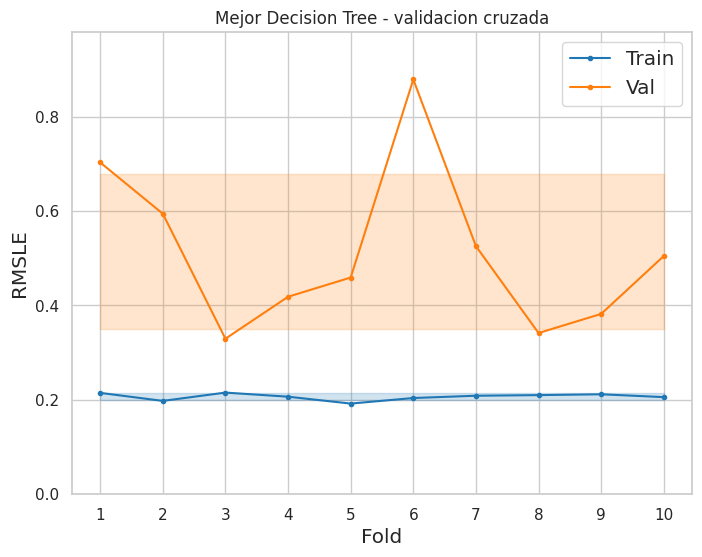

Train RMSLE: 0.2067 +/- 0.0070
Val RMSLE: 0.5137 +/- 0.1639


In [196]:
# Evaluar el mejor estimador encontrado con validación cruzada
from sklearn.model_selection import cross_validate

best_tree_cv_results = cross_validate(
    best_tree_regressor,
    df_train,
    y_train,
    cv=10,
    scoring=rmsle_scorer,
    return_train_score=True,
)

best_tree_rmsle_train = -best_tree_cv_results["train_score"]
best_tree_rmsle_val = -best_tree_cv_results["test_score"]

best_tree_mean_rmsle_train = best_tree_rmsle_train.mean()
best_tree_std_rmsle_train = best_tree_rmsle_train.std()
best_tree_mean_rmsle_val = best_tree_rmsle_val.mean()
best_tree_std_rmsle_val = best_tree_rmsle_val.std()
best_tree_folds = np.arange(1, len(best_tree_rmsle_train) + 1)

# Graficar los resultados de entrenamiento y validación para los folds
plt.figure(figsize=(8, 6))
plt.plot(best_tree_folds, best_tree_rmsle_train, ".-", color="tab:blue", label="Train")
plt.plot(best_tree_folds, best_tree_rmsle_val, ".-", color="tab:orange", label="Val")
plt.fill_between(
    best_tree_folds,
    best_tree_mean_rmsle_train + best_tree_std_rmsle_train,
    best_tree_mean_rmsle_train - best_tree_std_rmsle_train,
    color="tab:blue",
    alpha=0.2,
)
plt.fill_between(
    best_tree_folds,
    best_tree_mean_rmsle_val + best_tree_std_rmsle_val,
    best_tree_mean_rmsle_val - best_tree_std_rmsle_val,
    color="tab:orange",
    alpha=0.2,
)
plt.xlabel("Fold", fontsize="large")
plt.ylabel("RMSLE", fontsize="large")
plt.title("Mejor Decision Tree - validacion cruzada")
plt.legend(fontsize="large")
plt.xticks(best_tree_folds)
plt.ylim([0, max(best_tree_rmsle_val.max(), best_tree_rmsle_train.max()) + 0.1])
best_tree_cv_figure = plt.gcf()
plt.show()

print(f"Train RMSLE: {best_tree_mean_rmsle_train:.4f} +/- {best_tree_std_rmsle_train:.4f}")
print(f"Val RMSLE: {best_tree_mean_rmsle_val:.4f} +/- {best_tree_std_rmsle_val:.4f}")

In [197]:
# Explorar los resultados de GridSearchCV 
# Suponiendo que el GridSearchCV se llama gs_tree
# gs_tree.cv_results_ es un diccionario con los resultados
# gs_tree.best_estimator_ es el mejor modelo encontrado
# gs_tree.best_params_ es el mejor conjunto de hiper-parámetros encontrado
# gs_tree.best_score_ es el mejor score obtenido en validación cruzada para el mejor modelo
gs_tree_results = pd.DataFrame(gs_tree.cv_results_).copy()
cv_splits = gs_tree.cv if gs_tree.cv is not None else 5

def format_max_depth(value):
    if value is None or pd.isna(value):
        return "None"
    return str(int(value))

gs_tree_results["max_depth_label"] = gs_tree_results["param_regressor__max_depth"].apply(format_max_depth)

train_msle_columns = [f"split{split}_train_NMSLE" for split in range(cv_splits)]
test_msle_columns = [f"split{split}_test_NMSLE" for split in range(cv_splits)]
train_rmsle_by_split = np.sqrt(-gs_tree_results[train_msle_columns])
test_rmsle_by_split = np.sqrt(-gs_tree_results[test_msle_columns])

gs_tree_results["mean_train_RMSLE"] = train_rmsle_by_split.mean(axis=1)
gs_tree_results["std_train_RMSLE"] = train_rmsle_by_split.std(axis=1)
gs_tree_results["mean_test_RMSLE"] = test_rmsle_by_split.mean(axis=1)
gs_tree_results["std_test_RMSLE"] = test_rmsle_by_split.std(axis=1)

result_columns = [
    "max_depth_label",
    "mean_train_RMSLE",
    "std_train_RMSLE",
    "mean_test_RMSLE",
    "std_test_RMSLE",
    "rank_test_NMSLE",
]
display(gs_tree_results[result_columns].sort_values("rank_test_NMSLE"))

,max_depth_label,mean_train_RMSLE,std_train_RMSLE,mean_test_RMSLE,std_test_RMSLE,rank_test_NMSLE
7,12,0.206670,0.007326,0.513685,0.172805,1
8,15,0.110512,0.006630,0.528404,0.148525,2
6,10,0.298776,0.012231,0.526774,0.170081,3
10,None,0.008419,0.002578,0.543267,0.159904,4
9,20,0.034405,0.006040,0.545620,0.155048,5
5,8,0.414902,0.007887,0.574026,0.144556,6
4,6,0.524767,0.009422,0.636402,0.149342,7
3,5,0.591453,0.021299,0.693623,0.156904,8
2,4,0.671586,0.013674,0.765234,0.171384,9
1,3,0.741681,0.015393,0.841313,0.157277,10


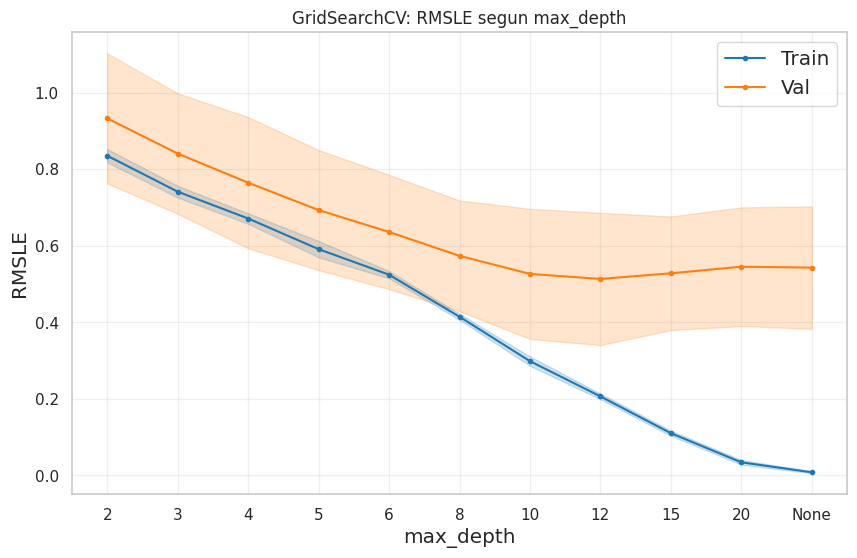

In [198]:
# Graficar los resultados de GridSearchCV 
# Para cada valor de max_depth, graficar el resultado de entrenamiento y validación
max_depth_labels = gs_tree_results["max_depth_label"].tolist()
x_positions = np.arange(len(max_depth_labels))

plt.figure(figsize=(10, 6))
plt.plot(x_positions, gs_tree_results["mean_train_RMSLE"], ".-", color="tab:blue", label="Train")
plt.plot(x_positions, gs_tree_results["mean_test_RMSLE"], ".-", color="tab:orange", label="Val")

plt.fill_between(
    x_positions,
    gs_tree_results["mean_train_RMSLE"] + gs_tree_results["std_train_RMSLE"],
    gs_tree_results["mean_train_RMSLE"] - gs_tree_results["std_train_RMSLE"],
    color="tab:blue",
    alpha=0.2,
)
plt.fill_between(
    x_positions,
    gs_tree_results["mean_test_RMSLE"] + gs_tree_results["std_test_RMSLE"],
    gs_tree_results["mean_test_RMSLE"] - gs_tree_results["std_test_RMSLE"],
    color="tab:orange",
    alpha=0.2,
)

plt.xticks(x_positions, max_depth_labels)
plt.xlabel("max_depth", fontsize="large")
plt.ylabel("RMSLE", fontsize="large")
plt.title("GridSearchCV: RMSLE segun max_depth")
plt.legend(fontsize="large")
plt.grid(alpha=0.3)
gs_tree_figure = plt.gcf()
plt.show()

In [199]:
# Imprimir el mejor RMSLE obtenido y el mejor conjunto de hiper-parámetros
best_grid_row = gs_tree_results.loc[gs_tree.best_index_]
best_grid_rmsle = best_grid_row["mean_test_RMSLE"]
best_grid_rmsle_std = best_grid_row["std_test_RMSLE"]
best_grid_max_depth = best_tree_params["regressor__max_depth"]

print(f"Mejor RMSLE promedio de validacion: {best_grid_rmsle:.4f} +/- {best_grid_rmsle_std:.4f}")
print(f"Mejor max_depth: {best_grid_max_depth}")
print(f"Mejores hiper-parametros: {best_tree_params}")

if "mean_rmsle_val" in globals():
    print(f"RMSLE validacion arbol sin ajuste fino: {mean_rmsle_val:.4f}")

Mejor RMSLE promedio de validacion: 0.5137 +/- 0.1728
Mejor max_depth: 12
Mejores hiper-parametros: {'regressor__max_depth': 12}
RMSLE validacion arbol sin ajuste fino: 0.5433


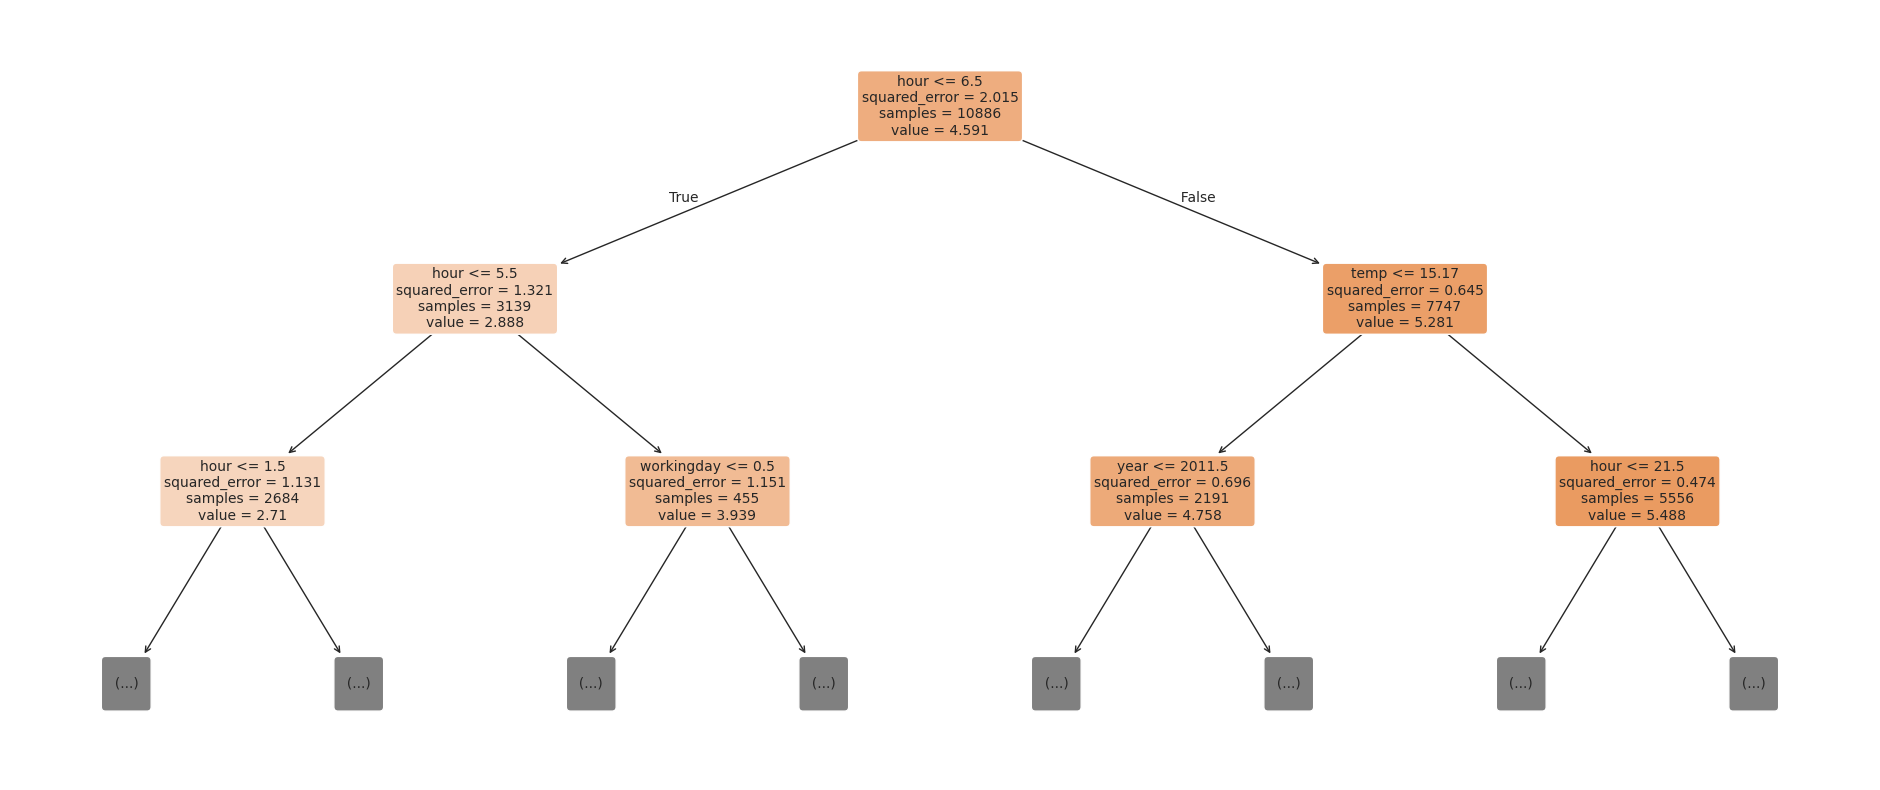

In [200]:
# Mostrar el arbol de decisión del mejor modelo encontrado
# Usar plot_tree del módulo tree de sklearn
# mostrar solo las primeras 2 capas del árbol para que sea legible
from sklearn import tree

plt.figure(figsize=(24, 10))
tree.plot_tree(
    best_tree_regressor.regressor_,
    feature_names=df_train.columns.tolist(),
    max_depth=2,
    filled=True,
    rounded=True,
    fontsize=10,
)
best_tree_plot_figure = plt.gcf()
plt.show()

In [201]:
# predecir sobre el conjunto de entrenamiento con el mejor modelo encontrado
y_train_pred_tree = best_tree_regressor.predict(df_train)
train_rmsle_best_tree = rmsle(y_train, y_train_pred_tree)

prediction_summary = pd.DataFrame(
    {
        "real": y_train.to_numpy(),
        "predicho": y_train_pred_tree,
    }
)

display(prediction_summary.head())
print(f"RMSLE sobre todo train: {train_rmsle_best_tree:.4f}")

,real,predicho
0,16,16.000000
1,40,40.000000
2,32,32.000000
3,13,13.637223
4,1,1.000000


RMSLE sobre todo train: 0.2043


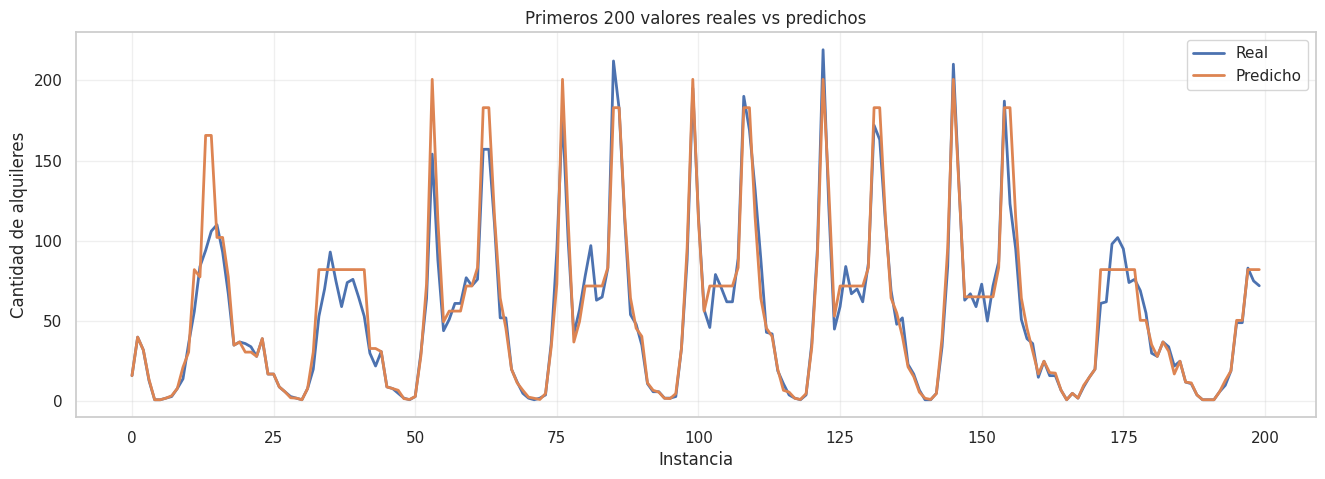

In [202]:
# Graficar los primeros N valores reales y predichos para comparar
N = 200
prediction_comparison = prediction_summary.iloc[:N].copy()

plt.figure(figsize=(16, 5))
plt.plot(prediction_comparison.index, prediction_comparison["real"], label="Real", linewidth=2)
plt.plot(prediction_comparison.index, prediction_comparison["predicho"], label="Predicho", linewidth=2)
plt.xlabel("Instancia")
plt.ylabel("Cantidad de alquileres")
plt.title(f"Primeros {N} valores reales vs predichos")
plt.legend()
plt.grid(alpha=0.3)
prediction_figure = plt.gcf()
plt.show()

Loguear a Comet y terminar el experimento

In [203]:
# loguear resultados del grid search en Comet
if exp_tree is not None:
    exp_tree.log_parameters(best_tree_params)
    exp_tree.log_parameter("hiperparametro_ajustado", "max_depth")
    exp_tree.log_metric("best_grid_rmsle", best_grid_rmsle)
    exp_tree.log_metric("best_tree_cv_train_rmsle", best_tree_mean_rmsle_train)
    exp_tree.log_metric("best_tree_cv_val_rmsle", best_tree_mean_rmsle_val)
    exp_tree.log_metric("train_rmsle_best_tree", train_rmsle_best_tree)

    for step, row in gs_tree_results.iterrows():
        exp_tree.log_metrics(
            {
                "grid_train_rmsle": row["mean_train_RMSLE"],
                "grid_val_rmsle": row["mean_test_RMSLE"],
            },
            step=int(step),
        )
        exp_tree.log_parameter(f"max_depth_step_{int(step)}", row["max_depth_label"])

    for figure_name, figure in [
        ("best_tree_cv", best_tree_cv_figure),
        ("grid_search_max_depth", gs_tree_figure),
        ("best_tree_plot_depth_2", best_tree_plot_figure),
        ("predicciones_train", prediction_figure),
    ]:
        exp_tree.log_figure(figure_name=figure_name, figure=figure)
else:
    print("Comet no esta activo; no se loguearon resultados.")

In [204]:
# terminar experimento en Comet
if exp_tree is not None:
    exp_tree.end()
    print("Experimento en Comet finalizado.")
else:
    print("No habia experimento de Comet activo para finalizar.")

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Decision Tree - ajuste fino max_depth
COMET INFO:     url                   : https://www.comet.com/srodriguez-lefebre/bike-sharing-demand/7685be4c82ec44049db69a71d5fb88b9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     best_grid_rmsle          : 0.513684990919999
COMET INFO:     best_tree_cv_train_rmsle : 0.20667043149640102
COMET INFO:     best_tree_cv_val_rmsle   : 0.513684990919999
COMET INFO:     grid_train_rmsle [11]    : (0.00841889728404458, 0.8356659887632581)
COMET INFO:     grid_val_rmsle [11]      : (0.513684990919999, 0.9332617156632951)
COMET INFO:     train_rmsle_best_tree    : 0.2042797959556248
COMET INFO:   Others:
COMET I

Experimento en Comet finalizado.


## Parte 5 - Random Forest

#### Preguntas sobre métodos de Ensamble:

*   ¿Cuáles son las ventajes de los métodos de Ensamble?
*   ¿A qué métodos de ensamble está asociado *Random Forest*?.
*   Importar la función *RandomForestRegressor()* de *Scikit-Learn*.
*   Indicar y describir los principales hiper-parámetros de un *RandomForestRegressor()*.




### Respuestas

- La ventaja principal es la combinacion de varios estimadores para poder lograr un modelo mas robusto que uno individual, ayudando a la generalizacion y reduccion de errores
- A bagging, entrena muchos arboles de deciciones sobre distintas muestras del conjunto de entrenamiento, ademas introduce aleatoriedad al considerar subconjuntos de caracteristicas. La prediccion final es el promedio de las predicciones de los arboles.
- los principales hiperparametros son, n_estimators para la cantidad de arboles, max_depth para la profundidad maxima, min_samples_leaf y min_samples_leaf. entre otras.

In [205]:
from sklearn.ensemble import RandomForestRegressor

#### Ajuste fino



*   Encontrar el mejor estimador para *Random Forest* con la configuración por defecto.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estándar e incluir esta última en el gráfico. Comparar con los resultados correspondientes de la parte 4.
*   Mostrar el mejor valor de RMSLE (promedio de todos los folds) y compararlo con el de la parte 4. Mostrar los valores seleccionados de los hiper-parámetros.
*   ¿Qué ventaja se pierde con repecto a usar un sólo árbol?
*   Graficar los primeros 200 valores objetivo junto con sus predicciones. Comparar con el gráfico correspondiente de la parte 4.
*   Mostrar la importancia de cada característica utilizando la variable *feature_importances_*.



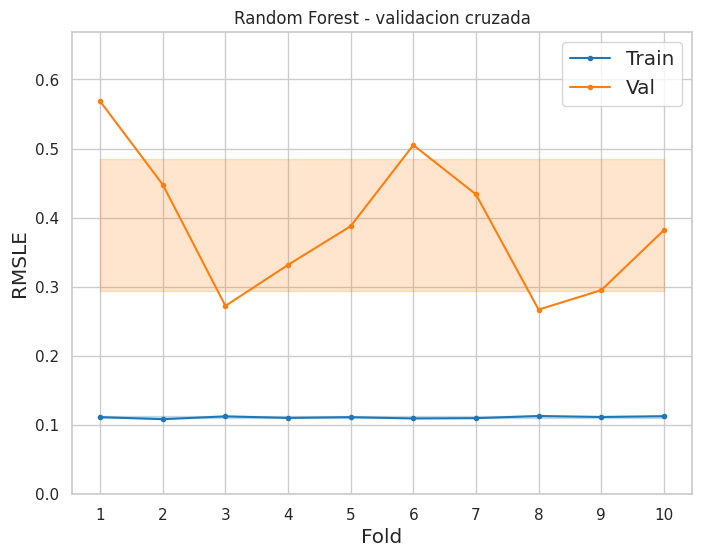

Random Forest Train RMSLE: 0.1112 +/- 0.0014
Random Forest Val RMSLE: 0.3891 +/- 0.0957
Mejor Decision Tree Val RMSLE: 0.5137
Diferencia RF - Decision Tree: -0.1245


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,random_state,n_jobs
0,100,None,2,1,1.0,True,2,-1


Con Random Forest se pierde interpretabilidad directa: ya no hay un unico arbol facil de visualizar, sino un promedio de muchos arboles. A cambio se reduce la varianza y mejora la estabilidad.


,real,predicho
0,16,19.165506
1,40,30.737237
2,32,25.515663
3,13,12.690500
4,1,1.652996


Random Forest RMSLE sobre todo train: 0.1105


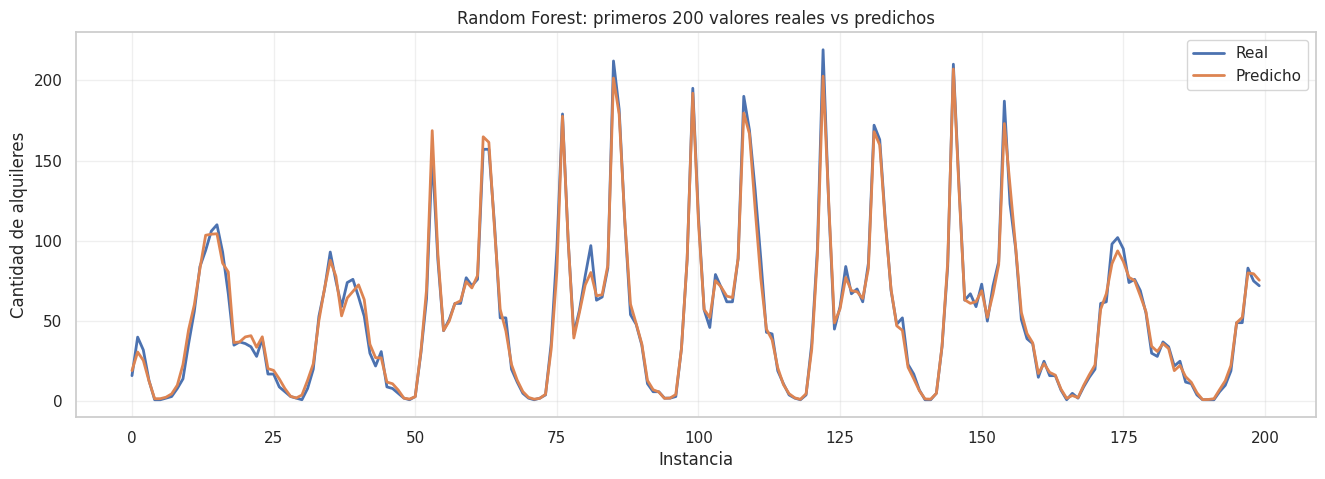

,feature,importance
11,hour,0.757790
4,temp,0.046239
2,workingday,0.038515
9,month,0.034003
10,year,0.032498
8,weekday,0.027515
6,humidity,0.018336
5,atemp,0.015960
3,weather,0.010547
7,windspeed,0.008967


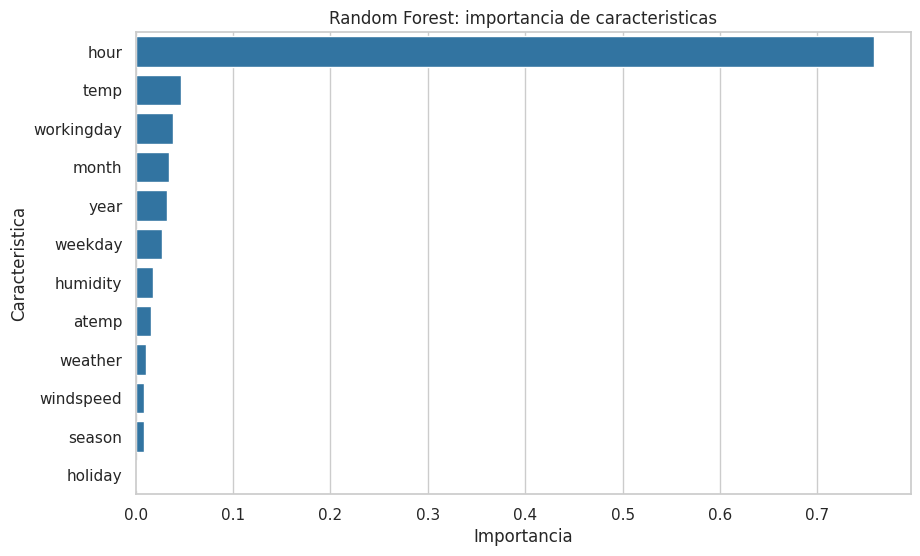

In [206]:
# Crear el estimador Random Forest con configuracion por defecto
# Se fija random_state para reproducibilidad y n_jobs=-1 para paralelizar.
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

rf_regressor = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=2, n_jobs=-1),
    func=np.log1p,
    inverse_func=np.expm1,
)

# Evaluar el estimador con validacion cruzada usando RMSLE
rf_cv_results = cross_validate(
    rf_regressor,
    df_train,
    y_train,
    cv=10,
    scoring=rmsle_scorer,
    return_train_score=True,
    n_jobs=-1,
)

rf_rmsle_train = -rf_cv_results["train_score"]
rf_rmsle_val = -rf_cv_results["test_score"]

rf_mean_rmsle_train = rf_rmsle_train.mean()
rf_std_rmsle_train = rf_rmsle_train.std()
rf_mean_rmsle_val = rf_rmsle_val.mean()
rf_std_rmsle_val = rf_rmsle_val.std()
rf_folds = np.arange(1, len(rf_rmsle_train) + 1)

# Graficar RMSLE de entrenamiento y validacion para los folds
plt.figure(figsize=(8, 6))
plt.plot(rf_folds, rf_rmsle_train, ".-", color="tab:blue", label="Train")
plt.plot(rf_folds, rf_rmsle_val, ".-", color="tab:orange", label="Val")
plt.fill_between(
    rf_folds,
    rf_mean_rmsle_train + rf_std_rmsle_train,
    rf_mean_rmsle_train - rf_std_rmsle_train,
    color="tab:blue",
    alpha=0.2,
)
plt.fill_between(
    rf_folds,
    rf_mean_rmsle_val + rf_std_rmsle_val,
    rf_mean_rmsle_val - rf_std_rmsle_val,
    color="tab:orange",
    alpha=0.2,
)
plt.xlabel("Fold", fontsize="large")
plt.ylabel("RMSLE", fontsize="large")
plt.title("Random Forest - validacion cruzada")
plt.legend(fontsize="large")
plt.xticks(rf_folds)
plt.ylim([0, max(rf_rmsle_val.max(), rf_rmsle_train.max()) + 0.1])
plt.show()

# Mostrar el mejor valor de RMSLE y comparar con Decision Tree
print(f"Random Forest Train RMSLE: {rf_mean_rmsle_train:.4f} +/- {rf_std_rmsle_train:.4f}")
print(f"Random Forest Val RMSLE: {rf_mean_rmsle_val:.4f} +/- {rf_std_rmsle_val:.4f}")

if "best_grid_rmsle" in globals():
    print(f"Mejor Decision Tree Val RMSLE: {best_grid_rmsle:.4f}")
    print(f"Diferencia RF - Decision Tree: {rf_mean_rmsle_val - best_grid_rmsle:.4f}")

# Mostrar los hiper-parametros usados por Random Forest
rf_params_to_show = [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
    "bootstrap",
    "random_state",
    "n_jobs",
]
rf_selected_params = {
    param: rf_regressor.regressor.get_params()[param]
    for param in rf_params_to_show
}
display(pd.DataFrame([rf_selected_params]))

# Responder que ventaja se pierde respecto a usar un solo arbol
print(
    "Con Random Forest se pierde interpretabilidad directa: ya no hay un unico arbol facil de visualizar, "
    "sino un promedio de muchos arboles. A cambio se reduce la varianza y mejora la estabilidad."
)

# Entrenar el estimador final sobre todo el conjunto de entrenamiento
rf_regressor.fit(df_train, y_train)
y_train_pred_rf = rf_regressor.predict(df_train)
train_rmsle_rf = rmsle(y_train, y_train_pred_rf)

rf_prediction_summary = pd.DataFrame(
    {
        "real": y_train.to_numpy(),
        "predicho": y_train_pred_rf,
    }
)

display(rf_prediction_summary.head())
print(f"Random Forest RMSLE sobre todo train: {train_rmsle_rf:.4f}")

# Graficar los primeros N valores objetivo junto con sus predicciones
N = 200
rf_prediction_comparison = rf_prediction_summary.iloc[:N].copy()

plt.figure(figsize=(16, 5))
plt.plot(rf_prediction_comparison.index, rf_prediction_comparison["real"], label="Real", linewidth=2)
plt.plot(rf_prediction_comparison.index, rf_prediction_comparison["predicho"], label="Predicho", linewidth=2)
plt.xlabel("Instancia")
plt.ylabel("Cantidad de alquileres")
plt.title(f"Random Forest: primeros {N} valores reales vs predichos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostrar la importancia de cada caracteristica
feature_importances = pd.DataFrame(
    {
        "feature": df_train.columns,
        "importance": rf_regressor.regressor_.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x="importance", y="feature", color="tab:blue")
plt.xlabel("Importancia")
plt.ylabel("Caracteristica")
plt.title("Random Forest: importancia de caracteristicas")
plt.show()


## Parte 6 - Gradient Boosting

#### XGBoost

*   Indicar cuál es la principal diferencia entre *Bagging* y *Boosting*.
*   Importar la función *XGBRegressor()* de la librería [*xgboost*](https://github.com/dmlc/xgboost).
*   Este estimador a diferencia de los anteriores puede devolver predicciones negativas para estos datos. Indicar en que caso se pueda dar esto y por qué esto no sucedía con los estimadores anteriores.
*   Las predicciones negativas no pueden ser evaluadas por RMSLE. Por lo tanto, crear una nueva función de evaluación que fuerce a cero todos los valores negativos de las predicciones y luego calcule el valor de RMSLE. Para esto se debe utilizar la función *make_score* de *Sickit-Learn*, para que la nueva función pueda ser utilizada en las funciones de selección de modelos.


**Nota:** *Scikit-Learn* ofrece una implementación de *Gradient Boosting*, pero *XGBRegressor()* es la implementación de [*eXtreme Gradient Boosting*](https://arxiv.org/pdf/1603.02754.pdf?__hstc=133736337.1bb630f9cde2cb5f07430159d50a3c91.1513641600097.1513641600098.1513641600099.1&__hssc=133736337.1.1513641600100&__hsfp=528229161) un variante del algoritmo tradicional que dentro de algunas ventajas requiere menos tiempo de entrenamiento. La implementación de las funciones de la librería son muy similares a las de *Scikit-Learn*, de igual forma aquí le dejamos un [ejemplo](https://www.kaggle.com/alexisbcook/xgboost) de cómo usarla. 







**Nota:** A partir de la versión **0.21** *Scikit-Learn* también ofrece una implementación de *Gradient Boosting* optimizada para data-sets grandes: [Histogram-based Gradient Boosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html). Su funcionamiento se basa en agrupar en *bins* a los features de entrada, remplazandolos por integers. El número de *bins* es controlado por el hiperparámetro *max_bins*, el cual por defecto toma el valor 255 y no puede ser seteado a un valor mayor que este. En el Capítulo 7 del libro se encuentra más información acerca de este algoritmo. 

#### Ajuste fino



*   Encontrar el mejor estimador para *Gradient Boosting* con la configuración por defecto.
*   Graficar los valores de RMSLE de entrenamiento y validación. Calcular la media y la desviación estandar e incluir esta última en el gráfico. Comparar con los gráficos correspondientes.
*   Mostrar el mejor valor de RMSLE (promedio de todos los folds) y compararlo con los anteriores. Mostrar los valores seleccionados de los hiper-parámetros.
*   Graficar los primeros 200 valores objetivo junto con sus predicciones. Comparar con los gráficos corespondientes.
*   ¿Qué compromiso hay entre los hiper-parámetros *n_estimators* y *learning_rate*?



## Parte 7 - Custom Transformers 

- Construir un *Custom Transformer* que extraiga las caracterísicas temporales, siguiendo el ejemplo del capítulo 2 del libro.

## Parte 8 - Generar un modelo

#### Objetivos:

 - Generar el mejor modelo posible. Se podrá explorar posibles mejoras en cualquiera de las siguientes etapas:

    - Parámetros óptimos del regresor.
    - Predicción de alquileres registered y casual por separado.
    - Separación de conjunto de Entrenamiento y Validación tomando en cuenta la generación del conjunto de Test del desafío.
    - Cambios en las características utilizadas. (Agregando o quitando alguna de ellas)

## Parte 9 - Submit
Construir un *pipeline* para el estimador que considere que tuvo mejor desempeño. El pre-procesamiento debe incluir la extracción de las nuevas características, si corresponde.

Subir los resultados del *pipeline* para los datos de *test*,  a la [página](https://www.kaggle.com/c/bike-sharing-demand/submissions) de la competencia.



*   ¿Cuánto fue el valor de RMSLE para el conjunto de test?
